In [2]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# and David Edel
# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

"""Simple example of QAT using DDP (ResNet on CIFAR-10)
Adapted from https://github.com/akamaster/pytorch_resnet_cifar10"""
# os.environ["TORCH_LOGS"]="recompiles"
import torch
import torch._dynamo

torch._dynamo.config.cache_size_limit = 64
torch._dynamo.config.recompile_limit = 64
# torch._dynamo.config.verbose = True
# torch._inductor.config.debug = True

import json
import torch.nn as nn
from torchvision import transforms as T
from torch import optim

import itertools

from model import resnet
from model.resnet import ResNet,BasicBlock
import wandb
import time


from tqpmod.parq_utils import (
    NORM_LAYERS,
    get_param_groups,
    split_param_groups,
    create_data_loaders,
)
from tqpmod.tqp_optimizer_scale_train import TQPS
# from tqpmod.softbinning import SoftBinning # replace with custom
from tqpmod.logging_utils import init_loger_and_folder
from tqpmod.train_eval import evaluate

import math # for nan check

DEVICE = torch.device("cuda:0")
torch.set_float32_matmul_precision("high")  # improves matmul speed
import matplotlib.pyplot as plt


In [3]:
class SoftBinningScale:
    def __init__(self, bins=3):
        if bins < 3 or bins % 2 != 1:
            raise ValueError("bins must be odd >= 3")
        self.bins = bins // 2
        self.max = self.bins

    @torch.no_grad()
    @torch.compile()
    def call_test(self, x: torch.Tensor):
        x = torch.abs(x)
        y = 1 - self.max + x
        mask = x < self.max
        y[mask] = x[mask] - torch.floor(x[mask])
        y = y * torch.abs(1 - y)
        return y

    def compute_xright_quantile(self, x: torch.Tensor):
        x, _ = x.clone().detach().flatten().sort()
        third = x[x.shape[0] // 3]
        two_thirds = x[int(x.shape[0] * (2 / 3))]
        return third.abs() + two_thirds.abs()


soft_binning = SoftBinningScale(3)

In [4]:
@torch.compile()
@torch.no_grad()
def calc_reg_loss_scale_layer(
    optimizer:TQPS,
    soft_binning: SoftBinningScale,
    n_params,
    device=torch.device("cuda:0"),
    M=1,
    beta=5e-4,
    compute_per_layer_share_done = False
):
    """
    returns tuple of:
    avg_reg_loss, a norm, %done
    """

    reg_loss = torch.zeros((), device=device, requires_grad=False)
    quantized_params = torch.zeros(
        (), device=device, requires_grad=False, dtype=torch.int64
    )
    norm = torch.zeros((), device=device, requires_grad=False)
    per_layer_share_done = torch.zeros((len(optimizer.regularized_params)))
    for i, param in enumerate(optimizer.regularized_params):
        
        reg_loss += soft_binning.call_test(param).sum().detach()

        calc_param = param.detach()
        quantized_this_param = (
            (abs(calc_param - calc_param.round().clip(-M, M)) < (beta / 2))
            .sum()
            .to(torch.int64))
        quantized_params += quantized_this_param
        
        per_layer_share_done[i] = quantized_this_param / param.numel()
        norm += param.norm().detach()

    return (reg_loss / n_params).item(), norm.sqrt().item(), (quantized_params / n_params).item(), per_layer_share_done

In [5]:
@torch.no_grad()
def factor_function_test(params):
    return (params.flatten().std() * 2 * 0.5) * torch.ones((params.shape[0],),device=params.device)
    # the 0.5 and 2 cancel, but leave them in because we could adjust the params for this

(array([100., 100., 100., 100., 100., 100., 100., 100., 100., 100.]),
 array([-1.72945428, -1.3835634 , -1.03767252, -0.69178176, -0.34589088,
         0.        ,  0.34589076,  0.69178176,  1.03767252,  1.38356328,
         1.72945428]),
 <BarContainer object of 10 artists>)

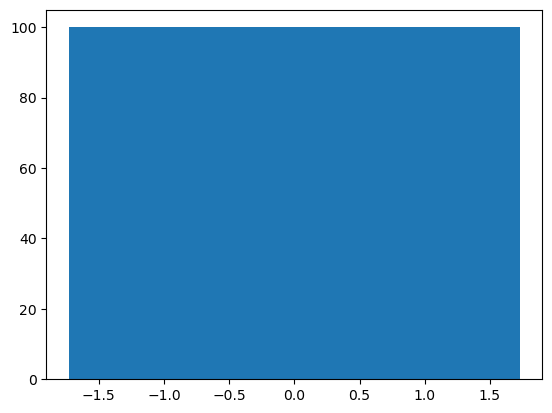

In [6]:
x = torch.linspace(-3.5,3.5,1000)
fac = factor_function_test(x)
plt.hist(x / fac)

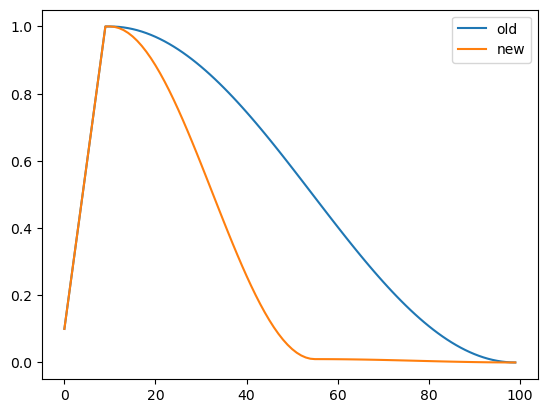

In [7]:
import numpy as np
num_epochs = 100
lr_warmup_epochs = 10
num_epochs_lr_schedule = 99
new_cos_epoch = 55
def get_lr_factor(epoch):
    if epoch < lr_warmup_epochs:
        return (epoch + 1) / lr_warmup_epochs
    elif epoch > num_epochs_lr_schedule:
        return get_lr_factor(num_epochs_lr_schedule)
    else:
        return max(
            [
                0.5
                * (
                    1
                    + np.cos(
                        np.pi
                        * (epoch - lr_warmup_epochs)
                        / (num_epochs_lr_schedule - lr_warmup_epochs)
                    )
                ) ,
                1e-9,
            ]
        )

percentage_new_cos = 0.01

def get_lr_factor_double_cos(epoch):
    if epoch < lr_warmup_epochs:
        return (epoch + 1) / lr_warmup_epochs
    elif epoch < new_cos_epoch:
        return max(
            [
                ( 0.5
                * (
                    1
                    + np.cos(
                        np.pi
                        * (epoch - lr_warmup_epochs)
                        / (new_cos_epoch - lr_warmup_epochs)
                    )
                ) ) * (1 - percentage_new_cos) + percentage_new_cos,
                1e-9,
            ]
        )
    else:
        return 0.5 * percentage_new_cos * (1 + np.cos(np.pi * (epoch-new_cos_epoch)/ (num_epochs - new_cos_epoch) ))
            
x = np.arange(100)
y = [get_lr_factor(xi) for xi in x]
y_new = [get_lr_factor_double_cos(xi) for xi in x]
plt.plot(x,y,label="old")
plt.plot(x,y_new,label="new")
plt.legend()

In [8]:
from tqdm import tqdm


def train_epoch(model, loader, criterion, optimizer, scaler, device,amp=False):
    model.train()
    running_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    total = 0  # cpu side, because we add ints to it (from shape) which are already on cpu and dont need to sync with the gpu

    pbar = tqdm(loader, desc="Training")
   
    for images, labels in pbar:

        torch.compiler.cudagraph_mark_step_begin()
        images: torch.Tensor
        labels: torch.Tensor
        images, labels = images.to(device, non_blocking=True), labels.to(
            device, non_blocking=True
        )


        # Mixed precision training
        optimizer.zero_grad()
        with torch.amp.autocast("cuda",enabled=amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            running_loss += loss.detach()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().detach()
            total += labels.size(0)


    avg_loss = running_loss.item() / len(loader)
    avg_accuracy = 100.0 * correct.item() / total
    #logger.info(f"loss {avg_loss:.4f}   acc {avg_accuracy:.2f}%")
    return avg_loss, avg_accuracy


In [9]:
from tqpmod.model_utils import inject_scale_layers, rebalance_layers
from typing import Any, Callable


def run(
    train_params: dict[str, Any], run_name: str = "base"
):
    try:
        logger, folder = init_loger_and_folder(run_name)
        history = {
            "train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": [],
        }

        # ALL these hyperparams could get overwritten by train_params
        num_epochs = 600  # 1000  # like 310
        num_epochs_lr_schedule = 599  # 999 # 300
        learning_rate = 0.1
        weight_decay = 2e-4

        lr_warmup_epochs = 10


        SEED = torch.randint(0, 10000, (1,))
        batch_size = 64


        if train_params is not None:
            num_epochs = train_params.get("num_epochs", num_epochs)
            num_epochs_lr_schedule = num_epochs - 1
            num_epochs_lr_schedule = train_params.get(
                "num_epochs_lr_schedule", num_epochs_lr_schedule
            )
            learning_rate = train_params.get("learning_rate", learning_rate)
            weight_decay = train_params.get("weight_decay", weight_decay)
            lr_warmup_epochs = train_params.get("lr_warmup_epochs", lr_warmup_epochs)
        
            SEED = train_params.get("SEED", SEED)
            batch_size = train_params.get("batch_size", batch_size)


        torch.manual_seed(SEED)
        train_loader, val_loader = create_data_loaders(
            "~/data",
            batch_size,
            11,
            False,
            SEED,
        )

        # define loss function (criterion) and optimizer
        scaler = torch.amp.GradScaler("cuda")
        label_smoothing = 0.1
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(DEVICE)  #
        model = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
        

        model = model.to(DEVICE)
        # specify number of quantization bits for different parameter groups

        # None indicates that it will need to get updated before starting training
        # param_groups_quant = [{"params:":[param],"quant_bits":0,"weight_decay": None,learning_rate:None} for param in params_quant]
        

        def build_lr_factor(lr_warmup_epochs, num_epochs_lr_schedule=None):
            num_epochs_lr_schedule = num_epochs_lr_schedule or (num_epochs - 1)

            def get_lr_factor(epoch):
                if epoch < lr_warmup_epochs:
                    return (epoch + 1) / lr_warmup_epochs
                elif epoch > num_epochs_lr_schedule:
                    return get_lr_factor(num_epochs_lr_schedule)
                else:
                    return max(
                        [
                            0.5
                            * (
                                1
                                + np.cos(
                                    np.pi
                                    * (epoch - lr_warmup_epochs)
                                    / (num_epochs_lr_schedule - lr_warmup_epochs)
                                )
                            ),
                            1e-9,
                        ]
                    )

            return get_lr_factor

        get_lr_factor: Callable = build_lr_factor(
            lr_warmup_epochs, num_epochs_lr_schedule
        )

        optimizer = torch.optim.SGD(
            model.parameters(),
            learning_rate,
            momentum=0.9,
            weight_decay=weight_decay,
            fused=True,  # test
        )
        lr_scheduler = optim.lr_scheduler.LambdaLR(
            optimizer, lr_lambda=get_lr_factor
        )

        best_acc = 0.0

        
        optimizer.zero_grad()
        model = torch.compile(model, mode="max-autotune", fullgraph=True, dynamic=False)
        torch.save(
            {
                "epoch": 0,
                "num_epochs": num_epochs,
                "SEED": SEED,
                "label_smoothing": label_smoothing,
                "lr_warmup_epochs": lr_warmup_epochs,
                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "current_acc": 0,
                "reg_loss": torch.inf,
                "lr_schedule": lr_scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "history": json.dumps(history),
                "best_acc": best_acc,
                "batch_size": batch_size,
            },
            f"{folder}/init_pre_train.pth",
        )
        with wandb.init(
            project="ResNet-TQP",
            name=f"{run_name}",
            config={
                "architecture": "ResNet20",
                "load_state": False,
                "Use Pretrained": f"{False}",
                "dataset": "CIFAR-10",
                "seed": SEED,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "optimizer": optimizer.__class__.__name__,
                "start_lr": learning_rate,
                "lr_warmup_epochs": lr_warmup_epochs,
                "weight_decay": weight_decay,
                "beta": None,
                "reg_wait_epochs": None,
                "label_smoothing": label_smoothing,
                "note": "no reg",
            },
            # mode="disabled"
        ) as run:

            for epoch in range(0, num_epochs):
                # for epoch in range(start_epoch, 350):
                # for epoch in range(num_epochs, num_epochs+20):
                start_time = time.time()
                logger.info(
                    f"\nEpoch [{epoch+1}/{num_epochs}] | LR: {optimizer.param_groups[0]['lr']:.10f}"
                )

                train_loss, train_acc = train_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer,
                    scaler,
                    DEVICE,
                    amp=True,
                )
                # TODO: compute change rate

                # keep REBALANCE_LAYERS and LR_SCHEDULER.STEP together, because we need to avoid training after rebalancing before updating learning rates
                lr_scheduler.step()
                # TODO: think about wd decay with scaled again!!
                # for param_group in optimizer.get_regularized_param_groups():
                #     param_group["weight_decay"] = weight_decay * get_lr_factor(epoch)

                
                # Save history
                history["train_loss"].append(train_loss)
                history["train_acc"].append(train_acc)

                logger.info(
                    f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%"
                )

                

                to_log = {
                    "lr": torch.tensor(lr_scheduler.get_last_lr()).mean().item(),
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                }

                if epoch % 2 == 1:
                    test_loss, test_acc = evaluate(model, val_loader, criterion, DEVICE)
                    history["test_acc"].append(test_acc)
                    history["test_loss"].append(test_loss)
                    logger.info(
                        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%"
                    )
                    to_log.update(
                        {
                            "test_loss": test_loss,
                            "test_acc": test_acc,
                        }
                    )
                    best_acc = max([test_acc, best_acc])

                    # to_log.update({f"change_rate_layer_{i}": cr for i, cr in enumerate(change_rates)})

                    # Save best model
                    if test_acc > best_acc:
                        best_acc = test_acc
                        torch.save(
                            {
                                "epoch": epoch,
                                "num_epochs": num_epochs,
                                "SEED": SEED,
                                "label_smoothing": label_smoothing,
                                "lr_warmup_epochs": lr_warmup_epochs,
                                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                                "model_state_dict": model.state_dict(),
                                "optimizer_state_dict": optimizer.state_dict(),
                                "current_acc": test_acc,
                                "lr_schedule": lr_scheduler.state_dict(),
                                "scaler": scaler.state_dict(),
                                "history": json.dumps(history),
                                "best_acc": best_acc,
                                "batch_size": batch_size,
                            },
                            f"{folder}/best_reg_loss_model.pth",
                        )
                        logger.info(
                            f"✓ Saved best model with best test accuracy: {test_acc:.2f}%"
                        )
                    else:
                        logger.info(
                            f"(X) model did not beat accuracy: {test_acc:.2f}%"
                        )
                    # health check:
                epoch_time = time.time() - start_time
                logger.info(f"Epoch Time: {epoch_time:.2f}s")
                to_log.update({"epoch time:": epoch_time})
                run.log(to_log, step=epoch)

    except Exception as e:
        logger.error(f"error: {e}")
    return history, model, optimizer

In [10]:
hist, model, optimizer = run(
     {"num_epochs": 300}, "300_no_reg"
)

2026-07-14 21:24:32 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/david/.netrc.
wandb: Currently logged in as: david-edel (david-edel-university-heidelberg-germany) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


2026-07-14 21:24:35 [INFO] 
Epoch [1/300] | LR: 0.0100000000
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:22<00:00, 35.29it/s]
2026-07-14 21:24:57 [INFO] Train Loss: 1.6808 | Train Acc: 44.65%
2026-07-14 21:24:57 [INFO] Epoch Time: 22.18s
2026-07-14 21:24:57 [INFO] 
Epoch [2/300] | LR: 0.0200000000
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:02<00:00, 345.60it/s]
2026-07-14 21:25:00 [INFO] Train Loss: 1.3657 | Train Acc: 61.21%
Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:10<00:00, 15.23it/s]
2026-07-14 21:25:10 [INFO] Test Loss: 1.4157 | Test Acc: 63.15%
2026-07-14 21:25:10 [INFO] (X) model did not bea

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇██
epoch time:,▁▇▇▁▁█▇▁▁▁▁▁█▇▁▁▇▁▇▁▇▁█▁█▁▇▁▁▁▁▁█▇▁▇▇█▁▇
lr,▂▅████████▇▇▇▇▇▇▆▆▆▆▅▅▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
test_acc,▂▁▂▂▂▃▃▃▃▂▃▂▁▃▂▄▄▄▅▅▄▅▄▅▅▆▆▆▇▇▇▇▇▇▇█████
test_loss,█▆▅▇▄▅▄▅▄▄▄▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁
train_acc,▁▁▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_loss,█▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,299
epoch time:,2.62156
lr,0.0
test_acc,92.88


In [11]:
for i in range(4):
    hist, model, optimizer = run({"num_epochs": 200}, "200_base_no_scale_no_reg")

2026-07-14 14:03:52 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


2026-07-14 14:03:54 [INFO] 
Epoch [1/200] | LR: 0.0100000000
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:19<00:00, 40.20it/s]
2026-07-14 14:04:13 [INFO] Train Loss: 1.6684 | Train Acc: 45.33%
2026-07-14 14:04:13 [INFO] Epoch Time: 19.48s
2026-07-14 14:04:13 [INFO] 
Epoch [2/200] | LR: 0.0200000000
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:02<00:00, 345.72it/s]
2026-07-14 14:04:16 [INFO] Train Loss: 1.3700 | Train Acc: 61.00%
Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:07<00:00, 21.50it/s]
2026-07-14 14:04:23 [INFO] Test Loss: 1.3321 | Test Acc: 66.41%
2026-07-14 14:04:23 [INFO] (X) model did not bea

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
epoch time:,▇▁▁▁▇█▁▇▇▁▁█▁██▁▁▇▁▇▇▁▁▁█▇▇▇▁█▇▁▁▇▁▁▇▁█▁
lr,▂▃▇███████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
test_acc,▁▃▃▄▅▄▃▅▅▄▅▄▄▄▅▃▄▆▅▅▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇█████
test_loss,█▇█▆▆▄▄▅▄▄▆▅▄▄▄▄▄▅▄▄▆▃▄▃▃▃▃▂▂▂▂▂▁▁▂▁▁▁▁▁
train_acc,▁▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁
epoch,199
epoch time:,2.61764
lr,0.0
test_acc,92.75


2026-07-14 14:12:33 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


2026-07-14 14:12:35 [INFO] 
Epoch [1/200] | LR: 0.0100000000
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:19<00:00, 40.27it/s]
2026-07-14 14:12:54 [INFO] Train Loss: 1.6817 | Train Acc: 44.26%
2026-07-14 14:12:54 [INFO] Epoch Time: 19.44s
2026-07-14 14:12:54 [INFO] 
Epoch [2/200] | LR: 0.0200000000
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:02<00:00, 344.71it/s]
2026-07-14 14:12:57 [INFO] Train Loss: 1.3703 | Train Acc: 60.82%
Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:07<00:00, 21.55it/s]
2026-07-14 14:13:04 [INFO] Test Loss: 1.8289 | Test Acc: 53.41%
2026-07-14 14:13:04 [INFO] (X) model did not bea

...

2026-07-14 14:21:16 [INFO] 
Epoch [1/200] | LR: 0.0100000000
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:19<00:00, 40.15it/s]
2026-07-14 14:21:35 [INFO] Train Loss: 1.6847 | Train Acc: 44.21%
2026-07-14 14:21:35 [INFO] Epoch Time: 19.50s
2026-07-14 14:21:35 [INFO] 
Epoch [2/200] | LR: 0.0200000000
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:02<00:00, 344.70it/s]
2026-07-14 14:21:37 [INFO] Train Loss: 1.3796 | Train Acc: 60.48%
Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:07<00:00, 21.48it/s]
2026-07-14 14:21:45 [INFO] Test Loss: 1.3262 | Test Acc: 64.35%
2026-07-14 14:21:45 [INFO] (X) model did not bea

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
epoch time:,▁▁▅▁▁▁▅▁▅▄▅▁▁▁▁▄▄▅▅▁▁▅▅▄▁▅▁▁▁▁▁▁▄▁▁▄▅▁▆█
lr,▃▅████████▇▇▇▇▇▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁
test_acc,▁▂▁▃▄▆▅▅▆▆▆▅▆▆▆▆▅▆▆▆▆▆▆▇▇▇▇▇▇▇██████████
test_loss,█▇▄▄▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████
train_loss,█▆▆▅▄▄▄▄▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁
epoch,199
epoch time:,2.92114
lr,0.0
test_acc,92.8


2026-07-14 14:30:00 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


2026-07-14 14:30:01 [INFO] 
Epoch [1/200] | LR: 0.0100000000
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:20<00:00, 37.97it/s]
2026-07-14 14:30:22 [INFO] Train Loss: 1.6675 | Train Acc: 45.05%
2026-07-14 14:30:22 [INFO] Epoch Time: 20.61s
2026-07-14 14:30:22 [INFO] 
Epoch [2/200] | LR: 0.0200000000
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:02<00:00, 336.68it/s]
2026-07-14 14:30:24 [INFO] Train Loss: 1.3648 | Train Acc: 61.30%
Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:07<00:00, 19.76it/s]
2026-07-14 14:30:32 [INFO] Test Loss: 1.4362 | Test Acc: 60.10%
2026-07-14 14:30:32 [INFO] (X) model did not bea

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇████
epoch time:,▁▅█▆█▇▆▆▇▇▆▆█▆█▆█████▅█▆█▆▅▅▅▇▆▇▆▆▆▆█▅▅█
lr,▃▄▅▇███████▇▇▇▇▇▆▆▆▅▅▅▅▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
test_acc,▁▁▃▃▄▄▄▄▅▅▄▄▄▄▅▅▆▅▆▆▅▆▆▆▆▇▇▇▇▇▇▇▇▇█▇████
test_loss,█▆▆▇█▅▅▄▅▅▅▅█▅▄▄▅▄▄▄▃▃▃▃▄▃▃▃▂▂▂▂▁▂▁▁▁▁▁▁
train_acc,▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇██
train_loss,█▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,199
epoch time:,4.05474
lr,0.0
test_acc,92.67


In [ ]:
for i in range(4):
    hist, model, optimizer = run({"num_epochs": 2000}, "200_base_no_scale_no_reg")

2026-07-14 14:43:08 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


2026-07-14 14:43:10 [INFO] 
Epoch [1/2000] | LR: 0.0100000000
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:23<00:00, 32.67it/s]
2026-07-14 14:43:34 [INFO] Train Loss: 1.6626 | Train Acc: 45.69%
2026-07-14 14:43:34 [INFO] Epoch Time: 23.98s
2026-07-14 14:43:34 [INFO] 
Epoch [2/2000] | LR: 0.0200000000
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:03<00:00, 216.16it/s]
2026-07-14 14:43:38 [INFO] Train Loss: 1.3611 | Train Acc: 61.49%
Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:08<00:00, 17.91it/s]
2026-07-14 14:43:47 [INFO] Test Loss: 1.2629 | Test Acc: 67.46%
2026-07-14 14:43:47 [INFO] (X) model did not b

epoch,▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
epoch time:,▆▇▇▆█▆▆▆▇█▄▆▂▂▂▂▂▂▂▂▇▆▆▇▆▆█▆█▆█▇▆▆▁▆█▆██
lr,████████▇▇▇▇▇▇▆▆▆▅▅▅▄▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
test_acc,▄▂▁▃▃▁▄▃▂▄▄▄▄▄▄▅▅▆▆▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇██▇███
test_loss,▄▆▅▆▄█▆▅▇▄▄▃▃▅▃▄▄▄▆▄▃▃▃▂▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁
train_acc,▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▇████
train_loss,█▆▆▆▆▅▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch,1999
epoch time:,3.85842
lr,0.0
test_acc,92.92


2026-07-14 16:38:18 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


2026-07-14 16:38:20 [INFO] 
Epoch [1/2000] | LR: 0.0100000000
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:23<00:00, 33.29it/s]
2026-07-14 16:38:44 [INFO] Train Loss: 1.6866 | Train Acc: 44.28%
2026-07-14 16:38:44 [INFO] Epoch Time: 23.54s
2026-07-14 16:38:44 [INFO] 
Epoch [2/2000] | LR: 0.0200000000
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:03<00:00, 216.22it/s]
2026-07-14 16:38:48 [INFO] Train Loss: 1.3551 | Train Acc: 61.86%
Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:08<00:00, 17.70it/s]
2026-07-14 16:38:57 [INFO] Test Loss: 1.3329 | Test Acc: 65.30%
2026-07-14 16:38:57 [INFO] (X) model did not b

In [12]:
model

OptimizedModule(
  (_orig_mod): ResNet(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), 

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  3.,  3.,  4., 14., 15., 16., 31.,
        63., 60., 80., 43., 26., 28., 14.,  8., 10.,  4.,  3.,  1.,  2.,
         1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-0.9216302 , -0.8609944 , -0.80035859, -0.73972273, -0.67908692,
        -0.61845112, -0.55781531, -0.49717951, -0.4365437 , -0.3759079 ,
        -0.31527209, -0.25463629, -0.19400042, -0.13336462, -0.07272881,
        -0.01209301,  0.0485428 ,  0.1091786 ,  0.16981441,  0.23045021,
         0.29108602,  0.35172182,  0.41235763,  0.47299343,  0.53362936,
         0.59426516,  0.65490097,  0.71553677,  0.77617258,  0.83680838,
         0.89744419,  0.95807999,  1.01871586,  1.07935166,  1.13998747,
         1.20062327]),
 <BarContainer object of 35 artists>)

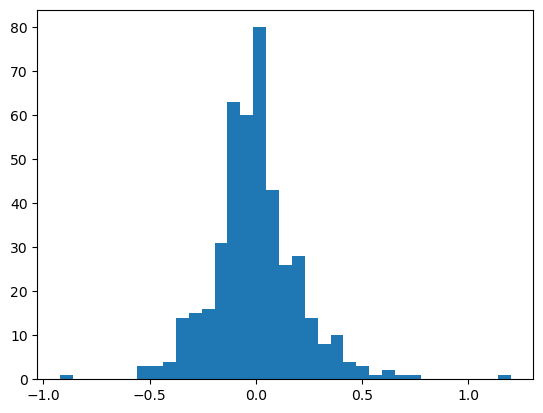

In [13]:
plt.hist(model.conv1.weight.data.detach().cpu().flatten() ,bins=35)

In [17]:
train_loader, val_loader = create_data_loaders(
    "~/data",
    64,
    11,
    False,
    32,
)
eval_loader = val_loader

In [18]:
from torch.utils.data import DataLoader, Subset
import random
from torchvision import datasets
normalize_transform = T.Normalize(
    mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
)

train_set = datasets.CIFAR10(
    "~/data",
    train=True,
    transform=T.Compose(
        [
            T.ToTensor(),
            normalize_transform,
        ]
    ),
    download=True,
)

train_loader_unaug = DataLoader(
    train_set,
    shuffle=True,
    batch_size=64,
    num_workers=11 ,
    pin_memory=True,
    persistent_workers=True ,
    drop_last=True ,
    )

In [19]:
from torch.utils.data import DataLoader, Subset
import random

def make_calib_loader(train_loader, num_samples=512, batch_size=None, seed=42):
    """
    Create a small calibration DataLoader by subsampling from an existing train_loader.

    Args:
        train_loader: the original training DataLoader
        num_samples: number of samples to use for calibration
        batch_size: batch size for calib_loader (defaults to train_loader's batch size)
        seed: for reproducible sampling

    Returns:
        calib_loader: a DataLoader over a random subset of the training dataset
    """
    dataset = train_loader.dataset
    batch_size = batch_size or train_loader.batch_size

    rng = random.Random(seed)
    num_samples = min(num_samples, len(dataset))
    indices = rng.sample(range(len(dataset)), num_samples)

    calib_subset = Subset(dataset, indices)
    calib_loader = DataLoader(
        calib_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=getattr(train_loader, "num_workers", 0),
    )
    return calib_loader

calib_loader = make_calib_loader(train_loader_unaug, num_samples=512)

In [22]:
import torch
import torch.nn as nn
from torch.ao.quantization import get_default_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx
import copy
import time

# -----------------------------
# 1. Load your trained model
# -----------------------------
# model = resnet18(weights=...)  # your trained fp32 model
if hasattr(model, "_orig_mod"):
    model = model._orig_mod
model.to(torch.device("cpu"))    
model.eval()
model_to_quantize = copy.deepcopy(model)

# -----------------------------
# 2. Set up qconfig
# -----------------------------
# 'x86' backend for server CPUs (uses fbgemm under the hood)
# use 'qnnpack' if targeting ARM/mobile
backend = "x86"
qconfig_mapping = get_default_qconfig_mapping(backend)
torch.backends.quantized.engine = backend

# -----------------------------
# 3. Prepare model (inserts observers)
# -----------------------------
example_inputs = next(iter(calib_loader))[0]  # a representative batch, shape [N, C, H, W]
prepared_model = prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)

# -----------------------------
# 4. Calibrate with representative data (no backward pass, just forward)
# -----------------------------
def calibrate(model, loader, num_batches=20):
    model.eval()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(loader):
            model(inputs)
            if i >= num_batches:
                break

calibrate(prepared_model, calib_loader, num_batches=20)

# -----------------------------
# 5. Convert to quantized model (int8)
# -----------------------------
quantized_model = convert_fx(prepared_model)
quantized_model.eval()

# -----------------------------
# 6. Evaluation function
# -----------------------------
@torch.no_grad()
def evaluate(model, dataloader, device="cpu"):
    model.eval()
    model.to(device)
    correct, total = 0, 0
    start = time.time()

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    elapsed = time.time() - start
    acc = correct / total
    print(f"Accuracy: {acc:.4f} | Total: {total} | Time: {elapsed:.2f}s")
    return acc

# -----------------------------
# 7. Compare FP32 vs INT8
# -----------------------------
print("FP32 model:")
evaluate(model, eval_loader, device="cpu")

print("INT8 quantized model:")
evaluate(quantized_model, eval_loader, device="cpu")

# -----------------------------
# 8. (Optional) Save the quantized model
# -----------------------------
torch.save(quantized_model.state_dict(), "resnet_int8.pth")
# Or, for full portability:
# scripted = torch.jit.script(quantized_model)
# scripted.save("resnet_int8_scripted.pt")

/tmp/ipykernel_236187/392022182.py:31: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                    

FP32 model:


/tmp/ipykernel_236187/392022182.py:49: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = convert_fx(prepared_model)


Accuracy: 0.9289 | Total: 10000 | Time: 9.03s
INT8 quantized model:
Accuracy: 0.9282 | Total: 10000 | Time: 1.45s
